# 06 · A Neural Network from Scratch

Every later chapter in this course hands the training loop to Keras or scikit-learn.
This chapter builds one **from scratch in plain NumPy** — forward pass, backward
pass, gradient descent — so the framework calls in chapters 08-09 aren't a black box.

**Objectives:** implement a small feedforward network, derive and code
backpropagation by hand, and train it with gradient descent on a toy classification
problem.

## 1. From one neuron to a network

A single artificial **neuron** takes a list of numbers, weighs each one, adds a
constant, and passes the result through a fixed function. With an input
$x \in \mathbb{R}^d$ (here $d = 2$: the two coordinates of a point), a weight vector
$w \in \mathbb{R}^d$ and a bias $b$ (a single number):

$$z = w^\top x + b = w_1 x_1 + \dots + w_d x_d + b, \qquad a = g(z).$$

$z$ is the **pre-activation**, a weighted vote of the inputs. $g$ is the **activation
function**, and $a$ is the neuron's output. The points where $z = 0$ form a straight
line in the plane (a hyperplane in higher dimensions), so one neuron on its own can
only split the plane with a straight cut.

Two activations appear in this chapter:

- **ReLU**, $\mathrm{ReLU}(z) = \max(0, z)$: it passes positive values and replaces
  negative ones by 0. Its derivative is 1 for $z > 0$ and 0 for $z < 0$.
- **Sigmoid**, $\sigma(z) = \dfrac{1}{1+e^{-z}}$: it maps any real number into
  $(0, 1)$, with $\sigma(0) = 0.5$, $\sigma(z) \to 1$ as $z \to +\infty$ and
  $\sigma(z) \to 0$ as $z \to -\infty$.

**A layer is many neurons at once.** Put $h$ neurons side by side, each with its own
weights. Their weight vectors form the columns of a matrix $W \in \mathbb{R}^{d\times h}$,
and their biases form a row $b \in \mathbb{R}^{1\times h}$. The code stores the $n$
points as the rows of a matrix $X \in \mathbb{R}^{n\times d}$, so a single matrix
product evaluates every neuron on every point:

$$Z = XW + b ,$$

with $b$ added to every row. Entry $Z_{ik}$ is neuron $k$'s pre-activation on point $i$.

**The network in this chapter** has a hidden layer of 8 ReLU neurons and one sigmoid
output neuron:

$$z_1 = X W_1 + b_1,\qquad a_1 = \mathrm{ReLU}(z_1),\qquad z_2 = a_1 W_2 + b_2,\qquad \hat y = \sigma(z_2).$$

| symbol | code | shape | meaning |
|---|---|---|---|
| $X$ | `X` | $n\times 2$ | inputs, one point per row |
| $W_1$, $b_1$ | `W1`, `b1` | $2\times 8$, $1\times 8$ | hidden-layer weights and biases |
| $z_1$, $a_1$ | `z1`, `a1` | $n\times 8$ | hidden pre-activations and outputs |
| $W_2$, $b_2$ | `W2`, `b2` | $8\times 1$, $1\times 1$ | output weights and bias |
| $z_2$, $\hat y$ | `z2`, `y_hat` | $n\times 1$ | output pre-activation and probability |

In total there are $2\cdot 8 + 8 + 8 + 1 = 33$ numbers to learn.

**Why the nonlinearity is essential.** Remove the ReLU, so that $a_1 = z_1$. Then

$$z_2 = (XW_1 + b_1)W_2 + b_2 = X\,(W_1W_2) + (b_1W_2 + b_2) = X W' + b' .$$

$W' = W_1W_2$ is a $2\times 1$ matrix and $b'$ is one number: the two layers collapse
into a single neuron, and the boundary is a straight line again. Any stack of linear
layers is one linear layer in disguise. The ReLU breaks this. Each hidden unit is
flat on one side of its own line and rises linearly on the other, and a weighted sum
of 8 such bent pieces can form a curved boundary.

## 2. A probability output and the cross-entropy loss

The label $y$ is 0 or 1. The output $\hat y = \sigma(z_2) \in (0,1)$ is read as the
network's estimate of the probability that $y = 1$. To train the network we need a
number that says how well such probabilities match the observed labels.

Treat $y$ as a coin flip, a **Bernoulli** variable, that lands on 1 with probability
$\hat y$. The probability the model gives to the label actually observed is

$$P(y \mid x) = \hat y^{\,y}\,(1-\hat y)^{1-y} .$$

This is $\hat y$ when $y = 1$ and $1-\hat y$ when $y = 0$, since any number to the power
0 equals 1. If the $n$ training labels are independent, the probability of all of
them together is the product $\prod_i P(y_i \mid x_i)$, called the **likelihood**. A
good model makes it large. Three small moves turn this into a loss: take the
logarithm (a product becomes a sum, and the maximiser does not change because $\log$
is increasing), flip the sign so that we minimise, and divide by $n$ to get an
average:

$$L = -\frac1n \sum_{i=1}^n \big[\,y_i\log \hat y_i + (1-y_i)\log(1-\hat y_i)\,\big].$$

This is the **binary cross-entropy**, `bce_loss` in the code. For one point with
$y = 1$ the loss is $-\log\hat y$: it is $0.105$ when $\hat y = 0.9$, $0.693$ when
$\hat y = 0.5$, and $4.6$ when $\hat y = 0.01$. Confident mistakes cost a lot, and the
loss grows without bound as $\hat y \to 0$.

## 3. Backpropagation: the chain rule, layer by layer

To improve the weights we need the **gradient**: how $L$ changes when each weight
changes slightly. The network is a chain of functions,
$X \to z_1 \to a_1 \to z_2 \to \hat y \to L$, and the **chain rule** says that the
derivative of a chain is the product of the derivatives of its links.
**Backpropagation** applies the chain rule from the loss backward, reusing each
result for the layer below. Write $\delta_2 = \partial L/\partial z_2$ and
$\delta_1 = \partial L/\partial z_1$; in the code they are `dz2` and `dz1`.

**Step 1: the output error.** For one point the loss is
$\ell = -[\,y\log\hat y + (1-y)\log(1-\hat y)\,]$. Its derivative with respect to
$\hat y$, over a common denominator, is

$$\frac{\partial \ell}{\partial \hat y} = -\frac{y}{\hat y} + \frac{1-y}{1-\hat y} = \frac{-y(1-\hat y) + (1-y)\hat y}{\hat y(1-\hat y)} = \frac{\hat y - y}{\hat y(1-\hat y)} .$$

The sigmoid's derivative follows from $\sigma(z) = (1+e^{-z})^{-1}$:

$$\sigma'(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \sigma(z)\big(1-\sigma(z)\big), \qquad\text{so}\qquad \frac{d\hat y}{dz_2} = \hat y\,(1-\hat y) .$$

Multiply the two links:

$$\frac{\partial \ell}{\partial z_2} = \frac{\hat y - y}{\hat y(1-\hat y)}\cdot \hat y(1-\hat y) = \hat y - y .$$

The awkward fractions cancel exactly. The error signal at the output is "prediction
minus truth": positive when the model said too much, negative when it said too
little, near zero when it is right. Because $L$ averages over $n$ points, row $i$ of
$\delta_2$ is $(\hat y_i - y_i)/n$. This is the first line of `backward`.

**Step 2: the output weights.** For point $i$, $z_{2,i} = \sum_k a_{1,ik}W_{2,k} + b_2$,
so $\partial z_{2,i}/\partial W_{2,k} = a_{1,ik}$. Adding the contributions of all
points:

$$\frac{\partial L}{\partial W_{2,k}} = \sum_i a_{1,ik}\,\delta_{2,i}
\quad\Longrightarrow\quad
\frac{\partial L}{\partial W_2} = a_1^\top \delta_2 ,\qquad
\frac{\partial L}{\partial b_2} = \sum_i \delta_{2,i} .$$

A weight's gradient is (the input flowing into that weight) times (the error at its
output), summed over points. A hidden unit that was silent on a point
($a_{1,ik} = 0$) takes no blame for it.

**Step 3: back into the hidden layer.** Hidden output $a_{1,ik}$ reaches $z_{2,i}$
through the weight $W_{2,k}$, so $\partial L/\partial a_{1,ik} = \delta_{2,i}W_{2,k}$, or
in matrix form

$$\frac{\partial L}{\partial a_1} = \delta_2 W_2^\top \qquad (n\times 8).$$

Then pass through the ReLU, whose derivative is 1 where $z_1 > 0$ and 0 elsewhere:

$$\delta_1 = \frac{\partial L}{\partial z_1} = \big(\delta_2 W_2^\top\big) \odot \mathbf{1}[z_1 > 0] .$$

Here $\odot$ is entry-by-entry multiplication and $\mathbf{1}[z_1 > 0]$ is a mask of
zeros and ones, `(z1 > 0)` in the code. Error flows back only through units that were
active.

**Step 4: the hidden weights.** This is Step 2 again, one layer down, with $X$ as the
input:

$$\frac{\partial L}{\partial W_1} = X^\top \delta_1 \quad (2\times 8),\qquad
\frac{\partial L}{\partial b_1} = \sum_i \delta_{1,i} \quad (1\times 8).$$

Every gradient has the same shape as the parameter it belongs to, which is a useful
check on the algebra.

## 4. Gradient descent, and one neuron by hand

The gradient points in the direction in which $L$ grows fastest. **Gradient
descent** takes a small step the opposite way, for every parameter $\theta$:

$$\theta \leftarrow \theta - \eta\,\frac{\partial L}{\partial \theta},$$

where the **learning rate** $\eta > 0$ sets the step size (`lr` in the code). Why this
lowers the loss: writing $g$ for the gradient, a first-order Taylor expansion gives
$L(\theta - \eta g) \approx L(\theta) - \eta\,\lVert g\rVert^2$. The change is negative
whenever $g \neq 0$ and $\eta$ is small enough for the approximation to hold.

**Worked example: one sigmoid neuron with two inputs.** Take the input $x = (1, 2)$,
label $y = 1$, weights $w = (0.5, -0.25)$, bias $b = 0$ and $\eta = 0.5$. For one
neuron the output shortcut is the same, $\partial\ell/\partial z = \hat y - y$, and
Step 2 gives $\partial\ell/\partial w_j = (\hat y - y)\,x_j$ and
$\partial\ell/\partial b = \hat y - y$.

| step | computation | value |
|---|---|---|
| pre-activation | $z = 0.5\cdot 1 + (-0.25)\cdot 2 + 0$ | $0$ |
| output | $\hat y = \sigma(0)$ | $0.5$ |
| loss | $-\log 0.5$ | $0.693$ |
| output error | $\hat y - y = 0.5 - 1$ | $-0.5$ |
| gradient for $w_1$ | $-0.5 \cdot 1$ | $-0.5$ |
| gradient for $w_2$ | $-0.5 \cdot 2$ | $-1.0$ |
| gradient for $b$ | $-0.5$ | $-0.5$ |
| new $w_1$ | $0.5 - 0.5\cdot(-0.5)$ | $0.75$ |
| new $w_2$ | $-0.25 - 0.5\cdot(-1.0)$ | $0.25$ |
| new $b$ | $0 - 0.5\cdot(-0.5)$ | $0.25$ |

With the new parameters, $z = 0.75\cdot1 + 0.25\cdot2 + 0.25 = 1.5$, so
$\hat y = \sigma(1.5) \approx 0.818$ and the loss is $-\log 0.818 \approx 0.201$, down
from $0.693$ after one step. The input $x_2 = 2$ is twice $x_1 = 1$, so $w_2$ moved
twice as far as $w_1$: each weight is adjusted in proportion to the input that flowed
through it.

**In the code.** `forward` computes `z1`, `a1`, `z2` and `y_hat` as in section 1.
`backward` computes, in order, `dz2` $= (\hat y - y)/n$, `dW2` $= a_1^\top\delta_2$,
`db2`, `da1` $= \delta_2 W_2^\top$, `dz1` (with the ReLU mask), `dW1` $= X^\top\delta_1$
and `db1`: the four steps of section 3. The training loop repeats forward pass, loss,
backward pass and the update of this section, with `lr = 0.5`, for 3000 passes over
the whole training set.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import mlutils
mlutils.set_style()
rng = np.random.default_rng(0)

## 5. The problem

`make_moons`: two interleaving crescents. Not linearly separable — no straight line
separates the classes — which is exactly why we need a nonlinear model at all. A
single-layer (linear) model provably cannot solve this; a network with even one
hidden layer of nonlinear units can.

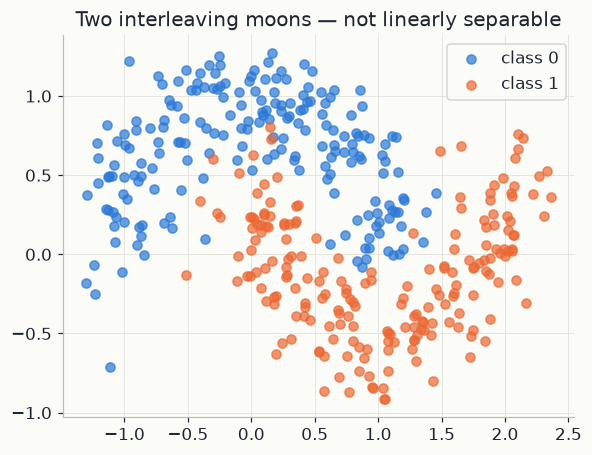

In [2]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
y_train_col, y_test_col = y_train.reshape(-1, 1), y_test.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(6, 4.5))
for cls, color in zip([0, 1], [mlutils.BLUE, mlutils.ORANGE]):
    sub = X[y == cls]
    ax.scatter(sub[:, 0], sub[:, 1], color=color, label=f"class {cls}", alpha=0.7)
ax.set(title="Two interleaving moons — not linearly separable")
ax.legend()

## 6. The network, forward pass

The network of section 1: one hidden layer of 8 ReLU units and a sigmoid output.

$$z_1 = X W_1 + b_1, \quad a_1 = \mathrm{ReLU}(z_1)$$
$$z_2 = a_1 W_2 + b_2, \quad \hat y = \sigma(z_2)$$

$\hat y \in (0, 1)$ is read as the model's estimated probability of class 1.
Parameters start as small random values — starting them at exactly zero would make
every hidden unit compute the same thing forever (a classic bug worth knowing about).

In [3]:
n_in, n_hidden, n_out = 2, 8, 1

W1 = rng.normal(size=(n_in, n_hidden)) * np.sqrt(2 / n_in)
b1 = np.zeros((1, n_hidden))
W2 = rng.normal(size=(n_hidden, n_out)) * np.sqrt(2 / n_hidden)
b2 = np.zeros((1, n_out))

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)
    return z1, a1, z2, y_hat

## 7. The loss, and backpropagation

The loss is the binary cross-entropy of section 2:

$$L = -\frac{1}{n}\sum_i \big[y_i \log \hat y_i + (1-y_i)\log(1-\hat y_i)\big]$$

`backward` codes the four steps of section 3, starting from the output error
$\partial L/\partial z_2 = (\hat y - y)/n$ and working down to the gradients of
`W1` and `b1`.

In [4]:
def backward(X, y, z1, a1, y_hat, W2):
    n = len(X)
    dz2 = (y_hat - y) / n                    # dL/dz2, the sigmoid+cross-entropy shortcut
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)                     # ReLU'(z1): 1 where z1>0, else 0
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def bce_loss(y, y_hat, eps=1e-9):
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

## 8. Training loop

Plain (full-batch) gradient descent: compute the loss and its gradient on the whole
training set, take a step, repeat.

In [5]:
lr = 0.5
losses, test_accs = [], []
for epoch in range(3000):
    z1, a1, z2, y_hat = forward(X_train, W1, b1, W2, b2)
    loss = bce_loss(y_train_col, y_hat)
    dW1, db1, dW2, db2 = backward(X_train, y_train_col, z1, a1, y_hat, W2)
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

    if epoch % 20 == 0:
        losses.append((epoch, loss))
        _, _, _, y_hat_test = forward(X_test, W1, b1, W2, b2)
        test_accs.append(((y_hat_test > 0.5).astype(int) == y_test_col).mean())

print(f"final training loss: {loss:.4f}")
print(f"final test accuracy: {test_accs[-1]:.3f}")

final training loss: 0.0674
final test accuracy: 0.960


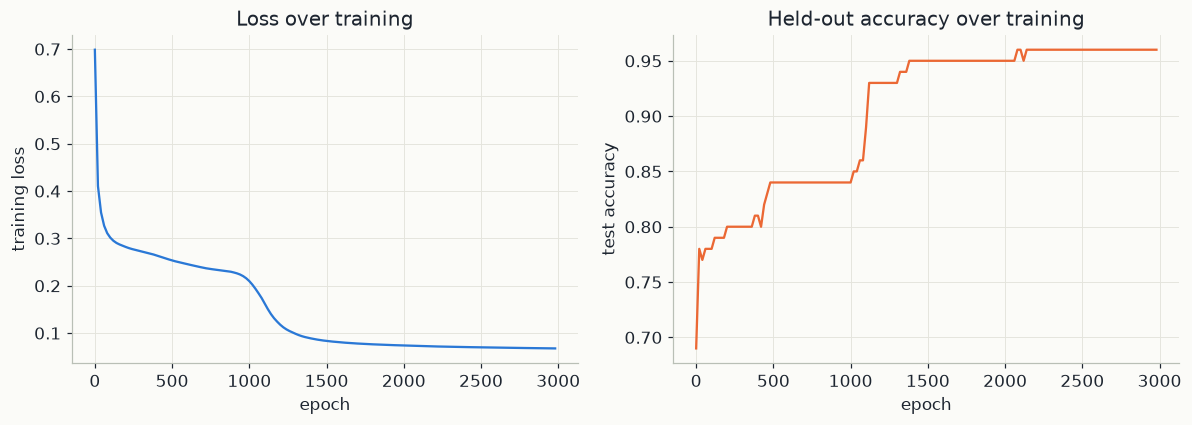

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs, loss_vals = zip(*losses)
axes[0].plot(epochs, loss_vals, color=mlutils.BLUE)
axes[0].set(xlabel="epoch", ylabel="training loss", title="Loss over training")
axes[1].plot(epochs, test_accs, color=mlutils.ORANGE)
axes[1].set(xlabel="epoch", ylabel="test accuracy", title="Held-out accuracy over training")
fig.tight_layout()

## 9. The learned decision boundary

[Text(0.5, 1.0, "A hand-written network's learned boundary — curved, not a straight line")]

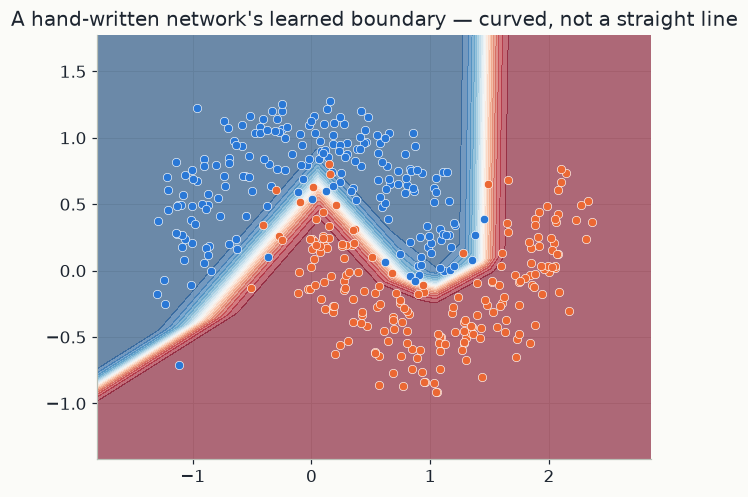

In [7]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                      np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
_, _, _, y_hat_grid = forward(grid, W1, b1, W2, b2)
Z = y_hat_grid.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
for cls, color in zip([0, 1], [mlutils.BLUE, mlutils.ORANGE]):
    sub = X[y == cls]
    ax.scatter(sub[:, 0], sub[:, 1], color=color, edgecolor="white", linewidth=0.4, s=30)
ax.set(title="A hand-written network's learned boundary — curved, not a straight line")

The boundary bends around the two moons — something no linear model could produce,
however it's trained. That curvature comes entirely from the ReLU nonlinearity
between the two layers; remove it (make the hidden layer linear) and the whole
network collapses back to an equivalent single linear model, boundary included.

## Exercises

### Exercise 1: Remove the nonlinearity
Change `relu(z1)` to just `z1` (identity — no nonlinearity) in `forward` and retrain.
What does the decision boundary look like now, and why?

<details><summary>Solution</summary>

With a linear hidden layer, $\hat y = \sigma((XW_1)W_2 + \ldots) = \sigma(X(W_1W_2) + \ldots)$
— the composition of two linear layers is still linear, so the boundary is a straight
line no matter how the network trains, and accuracy caps out well below the
nonlinear version's.
</details>

### Exercise 2: Learning rate and hidden width
Try `n_hidden = 2` and `n_hidden = 32`, and try `lr = 0.05` and `lr = 2.0`. Which
combination trains fastest without diverging? Relate a too-large learning rate here to
chapter 02's gradient descent exercise.

<details><summary>Solution</summary>

Too few hidden units (2) can't represent the moons' curvature well and accuracy
plateaus low; too high a learning rate makes the loss oscillate or diverge, exactly as
in chapter 02's single-parameter example, just harder to visualise in higher
dimensions.
</details>

## Key takeaways

- A feedforward network is two operations repeated: a linear map, then a nonlinear
  activation. Without the nonlinearity, stacking layers buys nothing.
- Backpropagation is the chain rule applied backward through the network's layers;
  for a sigmoid output with cross-entropy loss the output-layer gradient simplifies to
  $\hat y - y$.
- Gradient descent on this network is the same algorithm as chapter 02's one-variable
  example, just with thousands of parameters instead of one — the mechanics don't
  change, only the dimensionality.